In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Dataset 4_2

## S/ SMOTE

In [2]:
# -------- 1) Carregar dados --------
from pathlib import Path

candidate_files = [Path.cwd() / "data4_2.csv", Path.cwd() / "Final" / "data4_2.csv"]
csv_path = next((path for path in candidate_files if path.exists()), None)

if csv_path is None:
    raise FileNotFoundError("Não encontrei 'data4_2.csv' na pasta atual nem em 'Final'.")

df4_2 = pd.read_csv(csv_path)
print(f"Dataset carregado de: {csv_path}")

Dataset carregado de: c:\Users\Admin\Downloads\Códigos\Códigos\Final\data4_2.csv


In [3]:
# -------- 2) Definir target, drops e features --------
target4_2 = "SECClasS_Code_Ss_2_encode"
drop_cols4_2 = ["ElementID", "source", "is_rare_class", "SECClasS_Code_Ss_2"]

features4_2 = [
    "Volume", "Area", "Length", "Height", "Thickness/Width", "Base_offset", "Top_offset",
    "Number_of_Faces", "Bounding_Box_Width", "Bounding_Box_Height", "Bounding_Box_Depth",
    "Centroid_X", "Centroid_Y", "Centroid_Z", "Orientation_Angle", "Curvature",
    "Category_Curtain Panels", "Category_Doors", "Category_Floors", "Category_Roofs",
    "Category_Stairs", "Category_Structural Columns", "Category_Structural Foundations",
    "Category_Structural Framing", "Category_Walls", "Category_Windows",
    "load_bearing_status_binary"
]

In [4]:
# -------- 3) Preparar X e y --------
df_model = df4_2.drop(columns=drop_cols4_2, errors="ignore")
X = df_model[features4_2].copy()
y = df_model[target4_2].copy()

In [5]:
# -------- 4) Train/Test Split --------
X = X.replace([np.inf, -np.inf], np.nan)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test  = pd.DataFrame(imputer.transform(X_test),      columns=X.columns, index=X_test.index)

# Imputar X completo para usar na Validação Cruzada (CV)
X = pd.DataFrame(imputer.transform(X), columns=X.columns, index=X.index)


In [6]:
# ---------- 1) Modelos: SEM e COM SMOTE ----------
# 1a) SEM SMOTE
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
pred_no = dt.predict(X_test)

# 1b) COM SMOTE (aplicado só no treino)
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

dt_sm = DecisionTreeClassifier(random_state=42)
dt_sm.fit(X_train_sm, y_train_sm)
pred_sm = dt_sm.predict(X_test)

In [7]:
# ---------- 2) Métricas no TESTE ----------
def print_test_metrics(y_true, y_pred, tag):
    acc = accuracy_score(y_true, y_pred)
    bal = balanced_accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    f1w = f1_score(y_true, y_pred, average="weighted")
    print(f"\n=== TESTE — {tag} ===")
    print(f"Accuracy:         {acc:.4f}")
    print(f"Balanced Accuracy:{bal:.4f}")
    print(f"F1-macro:         {f1m:.4f}")
    print(f"F1-weighted:      {f1w:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))
    return acc, bal, f1m, f1w

acc_no, bal_no, f1m_no, f1w_no = print_test_metrics(y_test, pred_no, "Decision Tree (SEM SMOTE)")
acc_sm, bal_sm, f1m_sm, f1w_sm = print_test_metrics(y_test, pred_sm, "Decision Tree (COM SMOTE)")



=== TESTE — Decision Tree (SEM SMOTE) ===
Accuracy:         0.9781
Balanced Accuracy:0.9626
F1-macro:         0.9597
F1-weighted:      0.9780

Classification report:
              precision    recall  f1-score   support

           0     0.9474    0.9231    0.9351        39
           1     0.9832    0.9804    0.9818       358
           2     0.9866    0.9813    0.9839       374
           3     0.9696    0.9750    0.9723       360
           4     0.8974    0.9655    0.9302       145
           5     0.9521    0.9755    0.9636       163
           6     0.9471    0.9239    0.9354       368
           7     1.0000    1.0000    1.0000         9
           8     1.0000    0.9977    0.9989      1314
           9     1.0000    1.0000    1.0000       386
          10     0.9574    0.9574    0.9574        47
          11     0.9091    1.0000    0.9524        10
          12     0.9595    0.9861    0.9726        72
          13     1.0000    1.0000    1.0000        31
          14     1.000

In [8]:
import sys
from pathlib import Path

candidate_module_dirs = [Path.cwd(), Path.cwd() / "Final"]
for module_dir in candidate_module_dirs:
    if (module_dir / "inference_artifacts.py").exists():
        module_dir_str = str(module_dir)
        if module_dir_str not in sys.path:
            sys.path.insert(0, module_dir_str)

from inference_artifacts import ensure_artifact_dirs, save_model_bundle

dirs = ensure_artifact_dirs()
dt_no_path = save_model_bundle(
    name="decisiontree4_2_sem_smote",
    estimator=dt,
    imputer=imputer,
    features=X.columns,
    target_column=target4_2,
    class_labels=np.sort(np.unique(y)),
    metrics={"accuracy": acc_no, "balanced_accuracy": bal_no, "f1_macro": f1m_no, "f1_weighted": f1w_no},
    metadata={"algorithm": "DecisionTreeClassifier", "dataset": "data4_2.csv", "variant": "sem_smote", "source_notebook": "decisiontree4_2.ipynb"},
)
dt_sm_path = save_model_bundle(
    name="decisiontree4_2_com_smote",
    estimator=dt_sm,
    imputer=imputer,
    features=X.columns,
    target_column=target4_2,
    class_labels=np.sort(np.unique(y)),
    metrics={"accuracy": acc_sm, "balanced_accuracy": bal_sm, "f1_macro": f1m_sm, "f1_weighted": f1w_sm},
    metadata={"algorithm": "DecisionTreeClassifier", "dataset": "data4_2.csv", "variant": "com_smote", "source_notebook": "decisiontree4_2.ipynb"},
)

print(f"Modelo guardado em: {dt_no_path}")
print(f"Modelo guardado em: {dt_sm_path}")

Modelo guardado em: c:\Users\Admin\Downloads\Códigos\Códigos\Final\artifacts\models\decisiontree4_2_sem_smote.pkl
Modelo guardado em: c:\Users\Admin\Downloads\Códigos\Códigos\Final\artifacts\models\decisiontree4_2_com_smote.pkl


<Figure size 640x480 with 0 Axes>

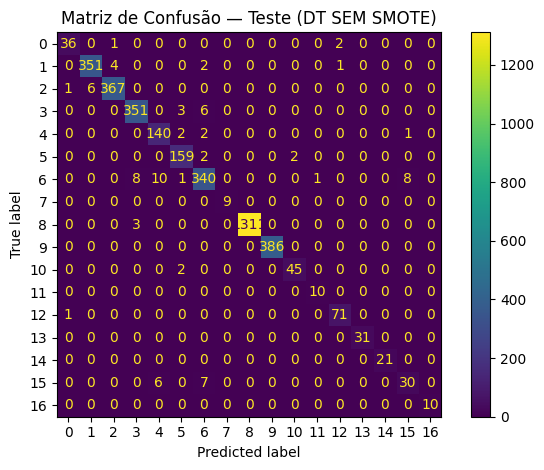

<Figure size 640x480 with 0 Axes>

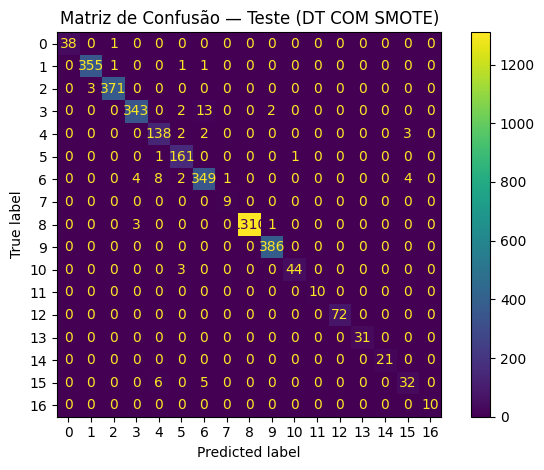

In [9]:
# ---------- 3) Matrizes de confusão (TESTE) ----------
plt.figure()
cm_no = confusion_matrix(y_test, pred_no, labels=np.sort(np.unique(y)))
ConfusionMatrixDisplay(confusion_matrix=cm_no, display_labels=np.sort(np.unique(y))).plot(values_format="d")
plt.title("Matriz de Confusão — Teste (DT SEM SMOTE)")
plt.tight_layout()
plt.show()

plt.figure()
cm_sm = confusion_matrix(y_test, pred_sm, labels=np.sort(np.unique(y)))
ConfusionMatrixDisplay(confusion_matrix=cm_sm, display_labels=np.sort(np.unique(y))).plot(values_format="d")
plt.title("Matriz de Confusão — Teste (DT COM SMOTE)")
plt.tight_layout()
plt.show()


Top 10 features — DT SEM SMOTE:
                        Feature  Importance
16      Category_Curtain Panels    0.281396
4               Thickness/Width    0.242187
24               Category_Walls    0.093912
21  Category_Structural Columns    0.077069
13                   Centroid_Z    0.061393
9           Bounding_Box_Height    0.046204
12                   Centroid_Y    0.041966
23  Category_Structural Framing    0.032869
2                        Length    0.020921
11                   Centroid_X    0.018300

Top 10 features — DT COM SMOTE:
                        Feature  Importance
4               Thickness/Width    0.199458
13                   Centroid_Z    0.108291
12                   Centroid_Y    0.084185
5                   Base_offset    0.072649
0                        Volume    0.062803
3                        Height    0.061206
24               Category_Walls    0.057276
16      Category_Curtain Panels    0.055791
8            Bounding_Box_Width    0.051244
21  Catego

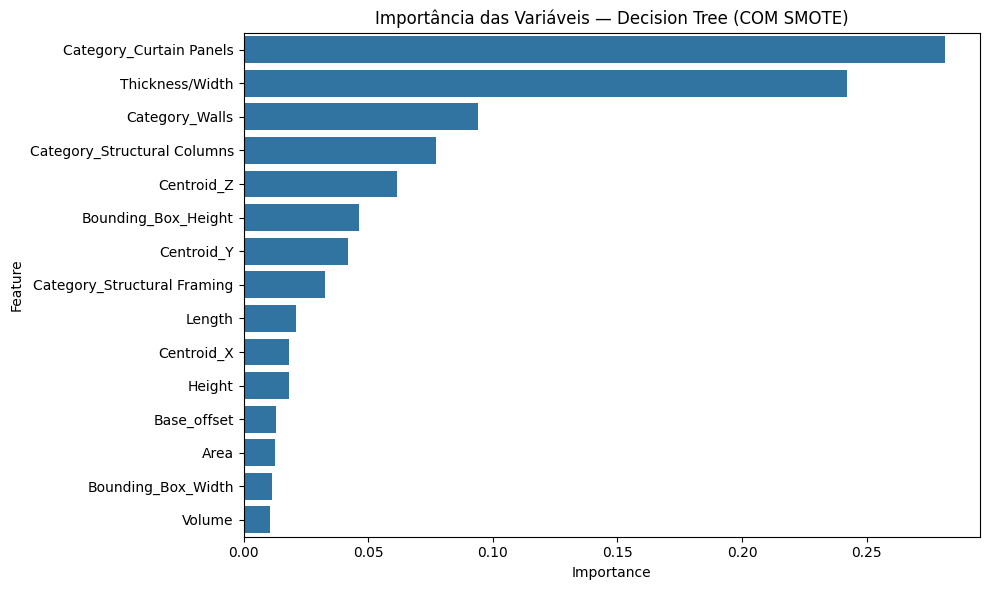

In [10]:
# ---------- 4) Importância das variáveis ----------
# Se tiveres a lista de features (ex.: features4_2), usa-a; senão usa X.columns
feature_names = getattr(X, "columns", [f"feat_{i}" for i in range(X.shape[1])])

imp_no = pd.DataFrame({"Feature": feature_names, "Importance": dt.feature_importances_}) \
            .sort_values("Importance", ascending=False)
imp_sm = pd.DataFrame({"Feature": feature_names, "Importance": dt_sm.feature_importances_}) \
            .sort_values("Importance", ascending=False)

print("\nTop 10 features — DT SEM SMOTE:")
print(imp_no.head(10))
print("\nTop 10 features — DT COM SMOTE:")
print(imp_sm.head(10))

# Gráfico Top-15 (SEM SMOTE)
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=imp_no.head(15))
plt.title("Importância das Variáveis — Decision Tree (COM SMOTE)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

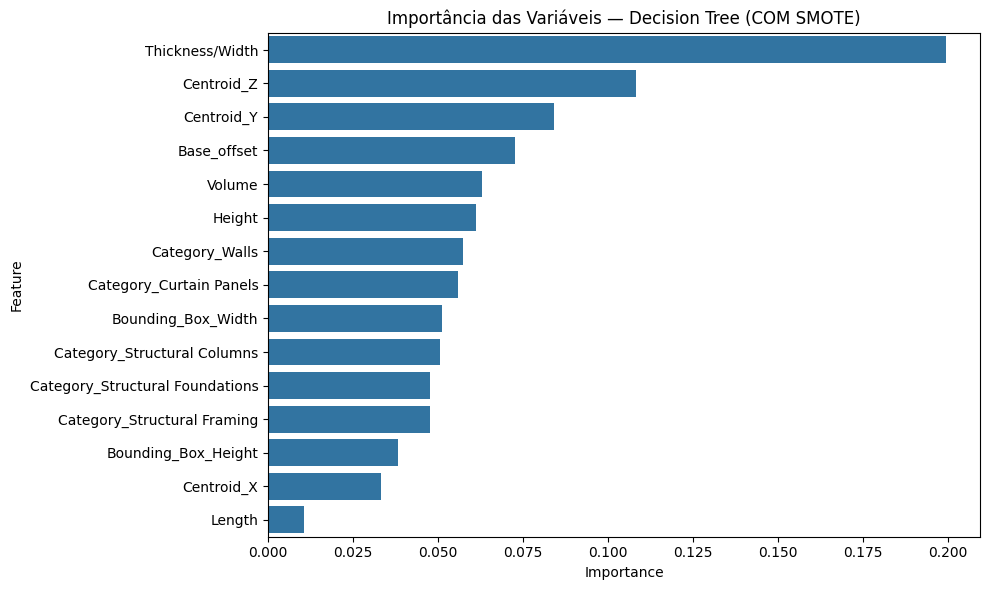

In [11]:
# Gráfico Top-15 (COM SMOTE)
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=imp_sm.head(15))
plt.title("Importância das Variáveis — Decision Tree (COM SMOTE)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [12]:
# ---------- 5) Validação Cruzada (5-fold) com múltiplas métricas ----------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorings = {
    "acc": "accuracy",
    "bal_acc": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
}

# 5a) SEM SMOTE
dt_cv = DecisionTreeClassifier(random_state=42)
cv_no = cross_validate(dt_cv, X, y, cv=cv, scoring=scorings, n_jobs=-1, return_train_score=False)

# 5b) COM SMOTE (pipeline para evitar leakage)
pipe_smote_dt = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("dt", DecisionTreeClassifier(random_state=42)),
])
cv_smote = cross_validate(pipe_smote_dt, X, y, cv=cv, scoring=scorings, n_jobs=-1, return_train_score=False)

def resumo_cv(nome, res):
    print(f"\n=== CV (5-fold) — {nome} ===")
    for k in scorings.keys():
        vals = res[f"test_{k}"]
        print(f"{k:12s}: {vals.mean():.4f} ± {vals.std():.4f}  (min={vals.min():.4f}, max={vals.max():.4f})")

resumo_cv("Decision Tree SEM SMOTE", cv_no)
resumo_cv("Decision Tree COM SMOTE", cv_smote)



=== CV (5-fold) — Decision Tree SEM SMOTE ===
acc         : 0.9827 ± 0.0018  (min=0.9811, max=0.9859)
bal_acc     : 0.9676 ± 0.0060  (min=0.9562, max=0.9723)
f1_macro    : 0.9658 ± 0.0041  (min=0.9615, max=0.9723)
f1_weighted : 0.9827 ± 0.0017  (min=0.9810, max=0.9858)

=== CV (5-fold) — Decision Tree COM SMOTE ===
acc         : 0.9822 ± 0.0023  (min=0.9779, max=0.9845)
bal_acc     : 0.9648 ± 0.0077  (min=0.9508, max=0.9720)
f1_macro    : 0.9642 ± 0.0065  (min=0.9530, max=0.9729)
f1_weighted : 0.9823 ± 0.0023  (min=0.9779, max=0.9845)



=== Matriz de Confusão — CV (SEM SMOTE) ===
     0     1     2     3    4    5     6   7     8     9    10  11   12   13  \
0   193     0     2     0    0    0     0   0     0     2    0   0    1    0   
1     1  1760    22     0    3    0     2   0     0     0    0   0    1    0   
2     1    15  1851     0    2    0     0   0     0     0    0   0    0    0   
3     0     0     0  1756    1    2    34   0     0     2    0   0    0    0   
4     1     0     2     0  683    9    16   0     0     0    0   0    0    0   
5     0     1     0     3    2  790     7   0     1     1   12   0    0    0   
6     0     1     0    33   14    4  1766   0     0     0    0   0    0    0   
7     0     0     0     0    0    0     0  44     0     0    0   0    0    0   
8     0     0     0    14    0    0     0   0  6554     0    0   0    0    0   
9     0     0     0     1    0    0     0   0     0  1928    0   0    0    0   
10    0     0     0     0    0   23     0   0     0     0  210   0    0    

<Figure size 640x480 with 0 Axes>

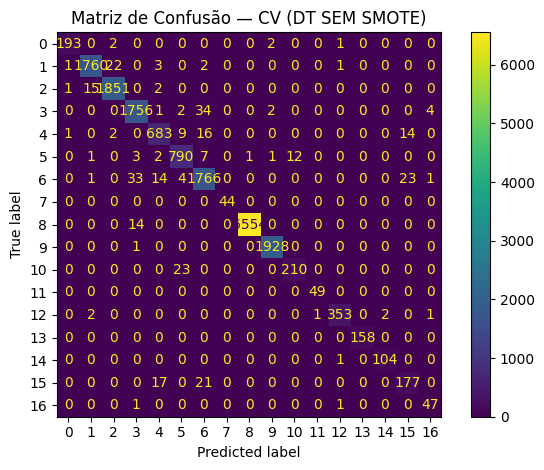

<Figure size 640x480 with 0 Axes>

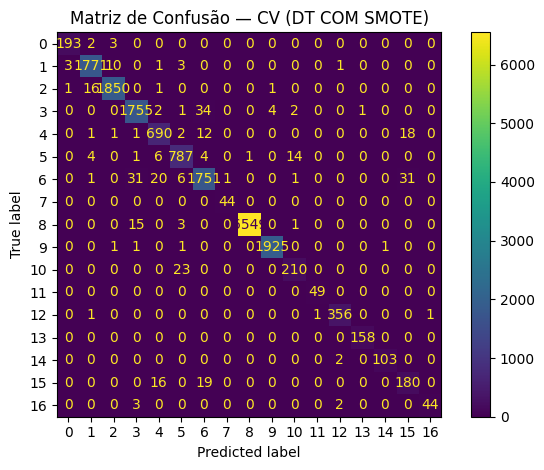

In [13]:
# ---------- 6) Matrizes de confusão out-of-fold (CV) ----------
y_pred_cv_no = cross_val_predict(dt_cv, X, y, cv=cv, n_jobs=-1)
y_pred_cv_sm = cross_val_predict(pipe_smote_dt, X, y, cv=cv, n_jobs=-1)

labels_sorted = np.sort(np.unique(y))

cm_cv_no = confusion_matrix(y, y_pred_cv_no, labels=labels_sorted)
cm_cv_sm = confusion_matrix(y, y_pred_cv_sm, labels=labels_sorted)

print("\n=== Matriz de Confusão — CV (SEM SMOTE) ===")
print(pd.DataFrame(cm_cv_no, index=labels_sorted, columns=labels_sorted))

print("\n=== Matriz de Confusão — CV (COM SMOTE) ===")
print(pd.DataFrame(cm_cv_sm, index=labels_sorted, columns=labels_sorted))

# (Opcional) Visualização
plt.figure()
ConfusionMatrixDisplay(confusion_matrix=cm_cv_no, display_labels=labels_sorted).plot(values_format="d")
plt.title("Matriz de Confusão — CV (DT SEM SMOTE)")
plt.tight_layout()
plt.show()

plt.figure()
ConfusionMatrixDisplay(confusion_matrix=cm_cv_sm, display_labels=labels_sorted).plot(values_format="d")
plt.title("Matriz de Confusão — CV (DT COM SMOTE)")
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# EXPORTAÇÃO DO MODELO PARA INFERÊNCIA
# ============================================================
# Guarda o encoder e os dois modelos treinados.
# Na inferência, os dados já chegam preparados pelo pipeline
# de data preparation, por isso não é necessário guardar o imputer.
#
# Ficheiros gerados (pasta Final/models/):
#   encoder_4_2.pkl   — LabelEncoder: converte número de volta para código SEC
#   dt_4_2.pkl       — Decision Tree treinado SEM SMOTE
#   dt_sm_4_2.pkl    — Decision Tree treinado COM SMOTE
# ============================================================

import joblib
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

# ---------- Pasta de destino ----------
models_dir = csv_path.parent / "models"
models_dir.mkdir(exist_ok=True)

# ---------- Encoder do target ----------
encoder = LabelEncoder()
encoder.fit(df4_2["SECClasS_Code_Ss_2"].astype(str))
joblib.dump(encoder, models_dir / "encoder_4_2.pkl")
print(f"[OK] Encoder guardado → {models_dir / 'encoder_4_2.pkl'}")

# ---------- Modelos ----------
joblib.dump(dt, models_dir / "dt_4_2.pkl")
print(f"[OK] Decision Tree (SEM SMOTE) guardado → {models_dir / 'dt_4_2.pkl'}")

joblib.dump(dt_sm, models_dir / "dt_sm_4_2.pkl")
print(f"[OK] Decision Tree (COM SMOTE) guardado → {models_dir / 'dt_sm_4_2.pkl'}")

print("\n=== Exportação concluída! ===")
print("Para fazer inferência em dados novos:")
print("  import joblib")
print("  encoder = joblib.load('Final/models/encoder_4_2.pkl')")
print("  model   = joblib.load('Final/models/dt_4_2.pkl')  # ou dt_sm_4_2.pkl")
print("  pred    = encoder.inverse_transform(model.predict(X_new))")

[OK] Encoder guardado → c:\Users\Admin\Downloads\Códigos\Códigos\Final\models\encoder_4_2.pkl
[OK] Decision Tree (SEM SMOTE) guardado → c:\Users\Admin\Downloads\Códigos\Códigos\Final\models\dt_4_2.pkl
[OK] Decision Tree (COM SMOTE) guardado → c:\Users\Admin\Downloads\Códigos\Códigos\Final\models\dt_sm_4_2.pkl

=== Exportação concluída! ===
Para fazer inferência em dados novos:
  import joblib
  encoder = joblib.load('Final/models/encoder_4_2.pkl')
  model   = joblib.load('Final/models/dt_4_2.pkl')  # ou dt_sm_4_2.pkl
  pred    = encoder.inverse_transform(model.predict(X_new))
